<a href="https://colab.research.google.com/github/drawcodeboy/Cat_n_Dog_Classification/blob/main/cat_n_dog_data_preprocessing_ver2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [77]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [78]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2
from PIL import Image

In [79]:
train_set = np.load('/content/drive/MyDrive/cat_n_dog/data_numpy/train_set.npy', allow_pickle=True)
test_set = np.load('/content/drive/MyDrive/cat_n_dog/data_numpy/test_set.npy', allow_pickle=True)

train_target = np.load('/content/drive/MyDrive/cat_n_dog/data_numpy/train_target.npy', allow_pickle=True)
test_target = np.load('/content/drive/MyDrive/cat_n_dog/data_numpy/test_target.npy', allow_pickle=True)

allow_pickle error
https://stackoverflow.com/questions/55890813/how-to-fix-object-arrays-cannot-be-loaded-when-allow-pickle-false-for-imdb-loa

In [80]:
print(train_set.shape, train_target.shape, test_set.shape, test_target.shape)

(8005,) (8005,) (2023,) (2023,)


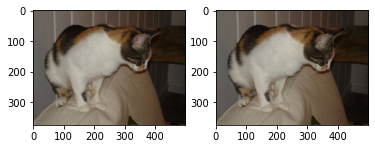

In [81]:
fig, axs = plt.subplots(1, 2)

axs[0].imshow(train_set[0])
axs[1].imshow(train_set[0] / 255.0)

plt.show()

In [82]:
# image_preprocessing: center cropping
def crop_center(img):
    y, x, z = img.shape
    crop_size = min(y, x)

    start_x = x // 2 - (crop_size // 2)
    start_y = y // 2 - (crop_size // 2)
    img = img[start_y:start_y + crop_size, start_x:start_x + crop_size]
    return cv2.resize(img, (224, 224))

reference: https://stackoverflow.com/questions/39382412/crop-center-portion-of-a-numpy-image

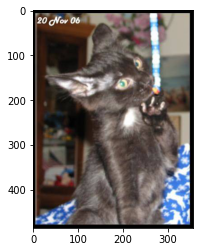

In [83]:
 plt.imshow(train_set[2])

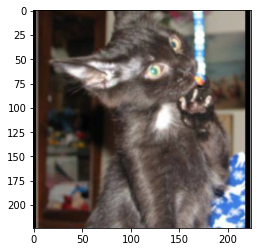

In [84]:
plt.imshow(crop_center(train_set[2]))

In [85]:
train_scaled = []

for i, img in enumerate(train_set):
    img_crop = crop_center(img)
    img_gray = cv2.cvtColor(img_crop, cv2.COLOR_BGR2GRAY)
    train_scaled.append(img_gray)

train_scaled = np.array(train_scaled)

del train_set # 더 이상 사용하지 않는 train_set 객체 변수 삭제 -> RAM 사용량 줄이기

In [86]:
test_scaled = []

for i, img in enumerate(test_set):
    img_crop = crop_center(img)
    img_gray = cv2.cvtColor(img_crop, cv2.COLOR_BGR2GRAY)
    test_scaled.append(img_gray)

test_scaled = np.array(test_scaled)

del test_set

(8005, 224, 224)


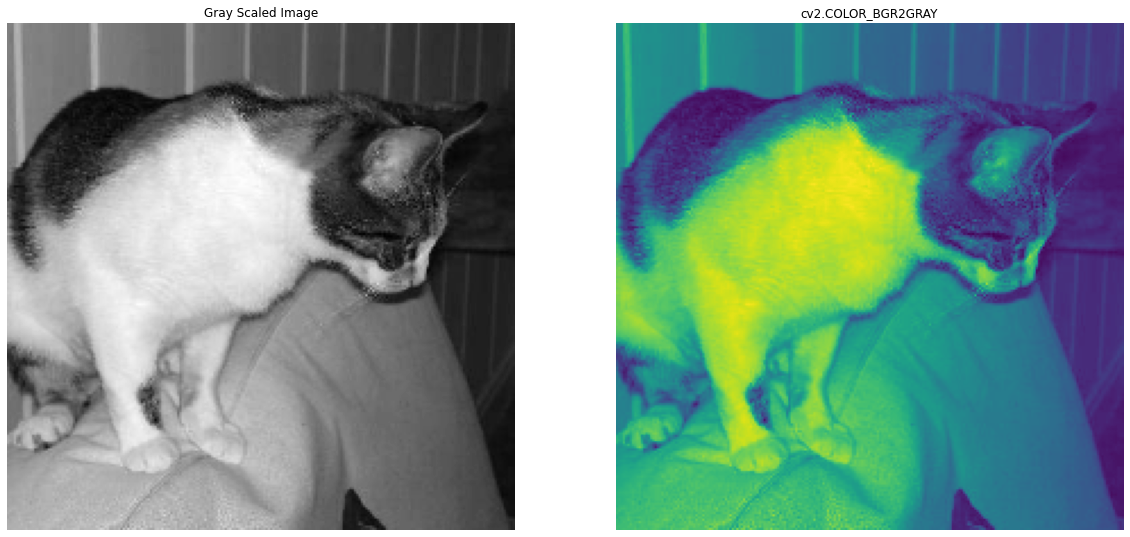

In [87]:
print(train_scaled.shape)

fig, axs = plt.subplots(1, 2, figsize=(20, 20))

axs[0].imshow(train_scaled[0], cmap='gray')
axs[1].imshow(train_scaled[0])

axs[0].set_title('Gray Scaled Image')
axs[1].set_title('cv2.COLOR_BGR2GRAY')

axs[0].axis('off')
axs[1].axis('off')

plt.show()

In [88]:
# 데이터 섞어주기
import random

shuffle_data = [[x, y] for x, y in zip(train_scaled, train_target)]
random.shuffle(shuffle_data)

x_train = [n[0] for n in shuffle_data]
y_train = [n[1] for n in shuffle_data]

x_train = np.array(x_train)
y_train = np.array(y_train)

Reference
https://jybaek.tistory.com/781

데이터를 섞어주지 않으므로써 fit 과정에서 비이상적인 현상이 일어났다.

Accuracy는 100%가 유지되지만 loss는 엄청 잠잠하다가 가끔 한 두번 거의 100 단위까지 뛰는 현상이 있었다.

이는 데이터를 섞어주지 않아 모델이 연속적으로 하나의 Target에 대해서만 학습하기 때문이었다.

In [93]:
# 분산적 처리
np.save('/content/drive/MyDrive/cat_n_dog/data_scaled_numpy/training_set_scaled/train_scaled_1', x_train[0:2000])
np.save('/content/drive/MyDrive/cat_n_dog/data_scaled_numpy/training_set_scaled/train_scaled_2', x_train[2000:4000])
np.save('/content/drive/MyDrive/cat_n_dog/data_scaled_numpy/training_set_scaled/train_scaled_3', x_train[4000:6000])
np.save('/content/drive/MyDrive/cat_n_dog/data_scaled_numpy/training_set_scaled/train_scaled_4', x_train[6000:])
np.save('/content/drive/MyDrive/cat_n_dog/data_scaled_numpy/test_set_scaled/test_scaled', test_scaled)

In [90]:
# train_target, train_set에 따른 분산처리
np.save('/content/drive/MyDrive/cat_n_dog/data_scaled_numpy/train_target_part/train_target_1', y_train[0:2000])
np.save('/content/drive/MyDrive/cat_n_dog/data_scaled_numpy/train_target_part/train_target_2', y_train[2000:4000])
np.save('/content/drive/MyDrive/cat_n_dog/data_scaled_numpy/train_target_part/train_target_3', y_train[4000:6000])
np.save('/content/drive/MyDrive/cat_n_dog/data_scaled_numpy/train_target_part/train_target_4', y_train[6000:])

# 현재 문제점

Normalization을 하면 메모리가 8배 늘어나서 RAM이 다운되어 전체적으로 런타임이 다운된다.

> 분산적으로 데이터셋을 나누어 저장하여 모델링 노트북에서 하나씩 가져와서 Normalization을 하며 처리